## Working on Mall Customer Dataset

In [1]:
import pandas as pd
import numpy as np
from warnings import filterwarnings
filterwarnings("ignore")


In [2]:
data = pd.read_csv('Mall_Customers.csv')
data.drop(columns=['CustomerID'], inplace=True)
print("Shape of the dataset is : ", data.shape)
data.head()

Shape of the dataset is :  (200, 4)


,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [3]:
for col in data.columns:
    print("No. of unique value in ", col, " are ", data[col].nunique())

No. of unique value in  Genre  are  2
No. of unique value in  Age  are  51
No. of unique value in  Annual Income (k$)  are  64
No. of unique value in  Spending Score (1-100)  are  84


In [4]:
data.isnull().sum()
# There are no null values in the dataset

Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [5]:
data.duplicated().sum()
# There are no duplicate values in the dataset

np.int64(0)

In [6]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.0,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.0,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.0,99.0


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Genre                   200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


Text(0.5, 1.0, 'Age vs Spending Score (1-100)')

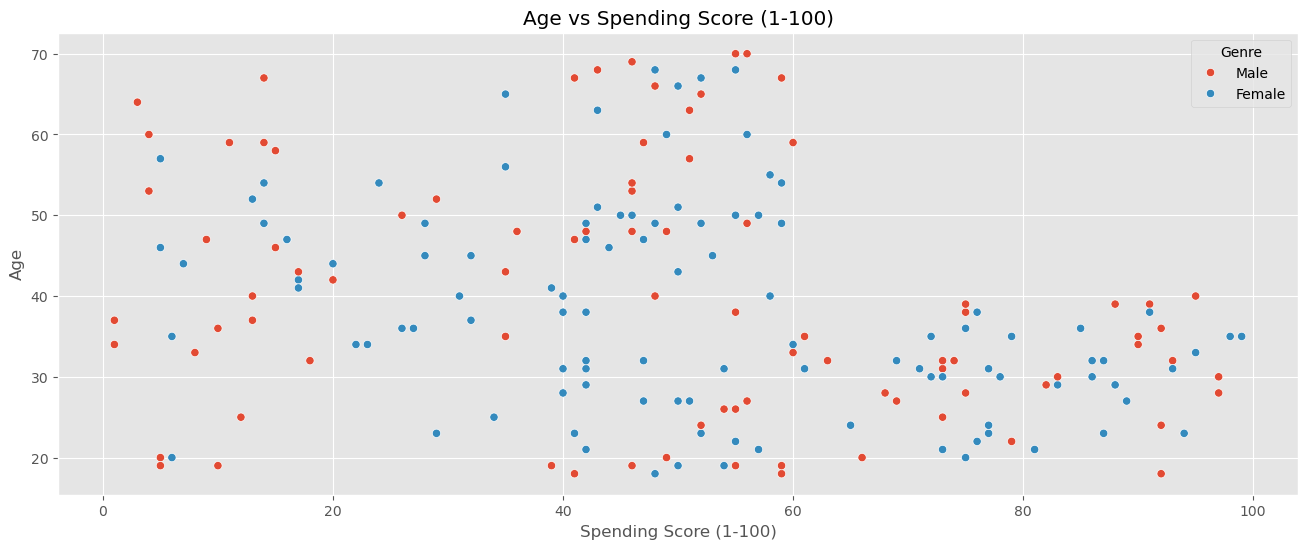

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
plt.figure(figsize=(16,6))
sns.scatterplot(y = data['Age'], x=data['Spending Score (1-100)'], hue=data['Genre'])
plt.title('Age vs Spending Score (1-100)')

We can see that people with `Age` less than 40 mostly have more than `40`. Also very few people have more than `60 Spending Power` for people older than `40 years`.

Text(0.5, 1.0, 'Annual Income vs Spending Score (1-100)')

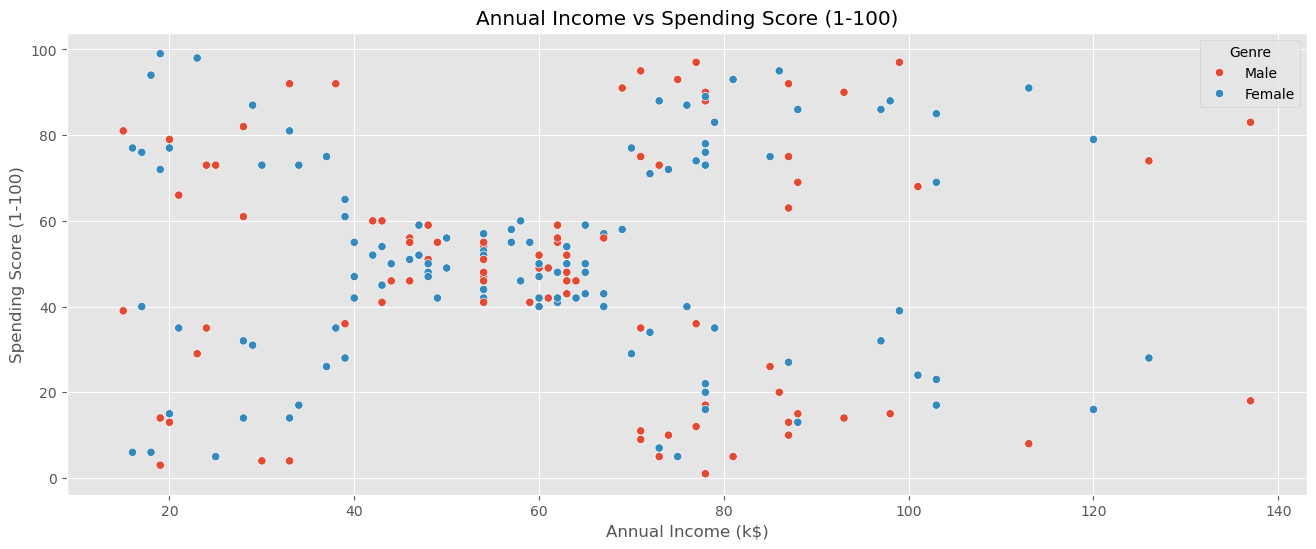

In [9]:
plt.figure(figsize=(16,6))
sns.scatterplot(x = data['Annual Income (k$)'], y=data['Spending Score (1-100)'], hue=data['Genre'])
plt.title('Annual Income vs Spending Score (1-100)')

People having Salary between `40k and 70k` have spending between `40 and 60` which is an unusual behaviour. 

In [10]:
data.columns

Index(['Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

<Axes: ylabel='Spending Score (1-100)'>

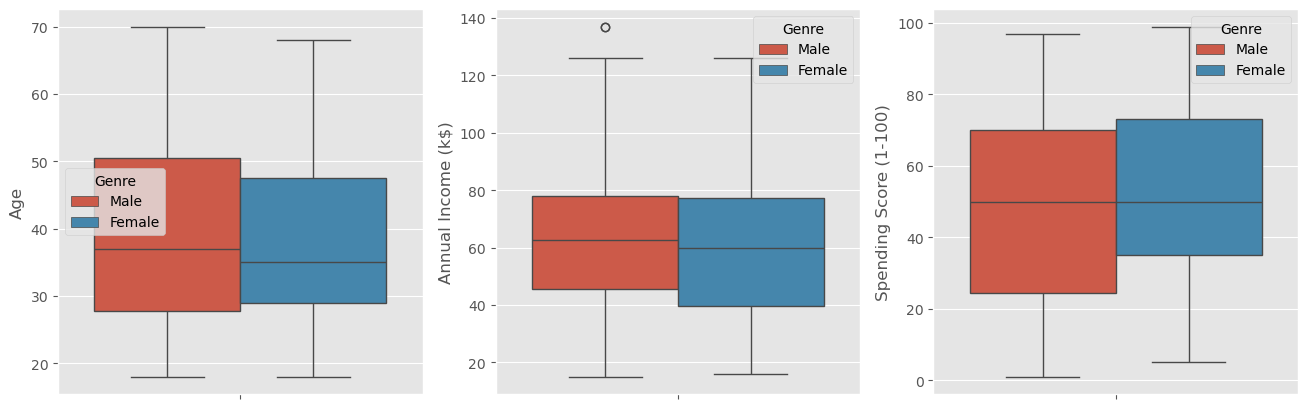

In [11]:
plt.figure(figsize=(16,5))
plt.subplot(1,3,1)
sns.boxplot(data = data, y='Age', hue='Genre')
# plt.title('Boxplot of Age')
plt.subplot(1,3,2)
sns.boxplot(data = data,y='Annual Income (k$)', hue='Genre')
# plt.title('Boxplot of Annual Income (k$)')
plt.subplot(1,3,3)
sns.boxplot(data = data,y='Spending Score (1-100)', hue='Genre')
# plt.title('Boxplot of Spending Score (1-100)')

Text(0.5, 1.0, 'Mean of Age, Annual Income, and Spending Score')

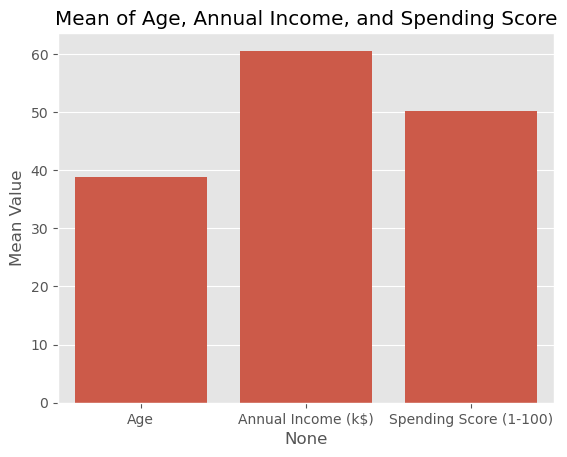

In [12]:


# Show means of relevant columns as a bar plot
means = data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
sns.barplot(x=means.index, y=means.values)
plt.ylabel("Mean Value")
plt.title("Mean of Age, Annual Income, and Spending Score")

## Step 2

Text(0.5, 1.0, 'Annual Income vs Spending Score (1-100)')

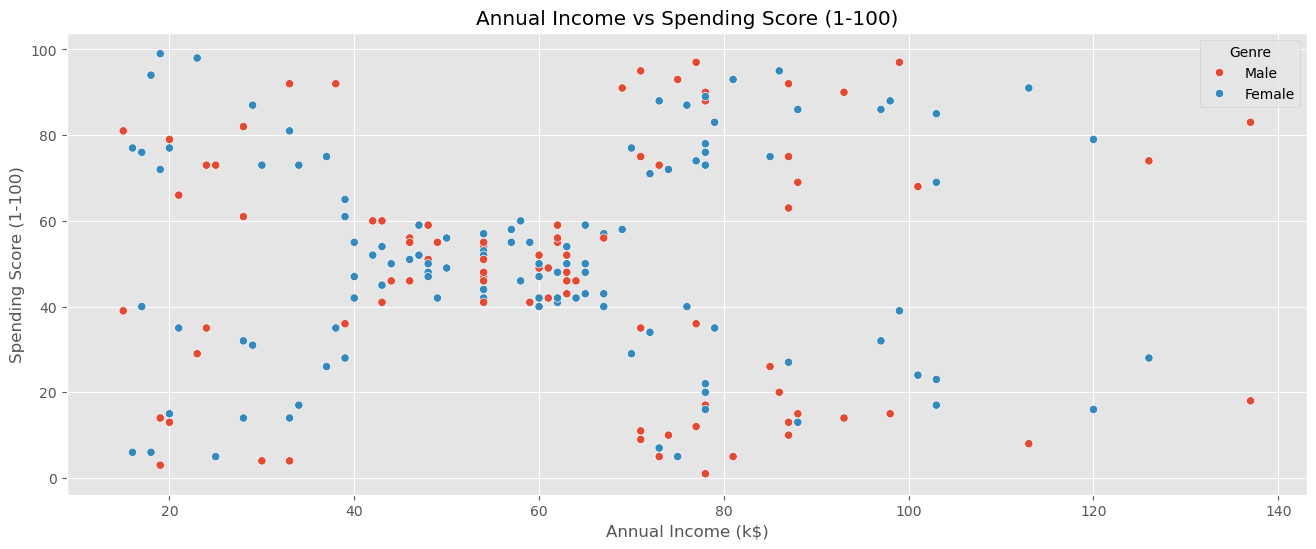

In [13]:
plt.figure(figsize=(16,6))
sns.scatterplot(x = data['Annual Income (k$)'], y=data['Spending Score (1-100)'], hue=data['Genre'])
plt.title('Annual Income vs Spending Score (1-100)')

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])
data_scaled = pd.DataFrame(data_scaled, columns=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'])
data_scaled.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


Text(0.5, 1.0, 'Annual Income vs Spending Score (1-100)')

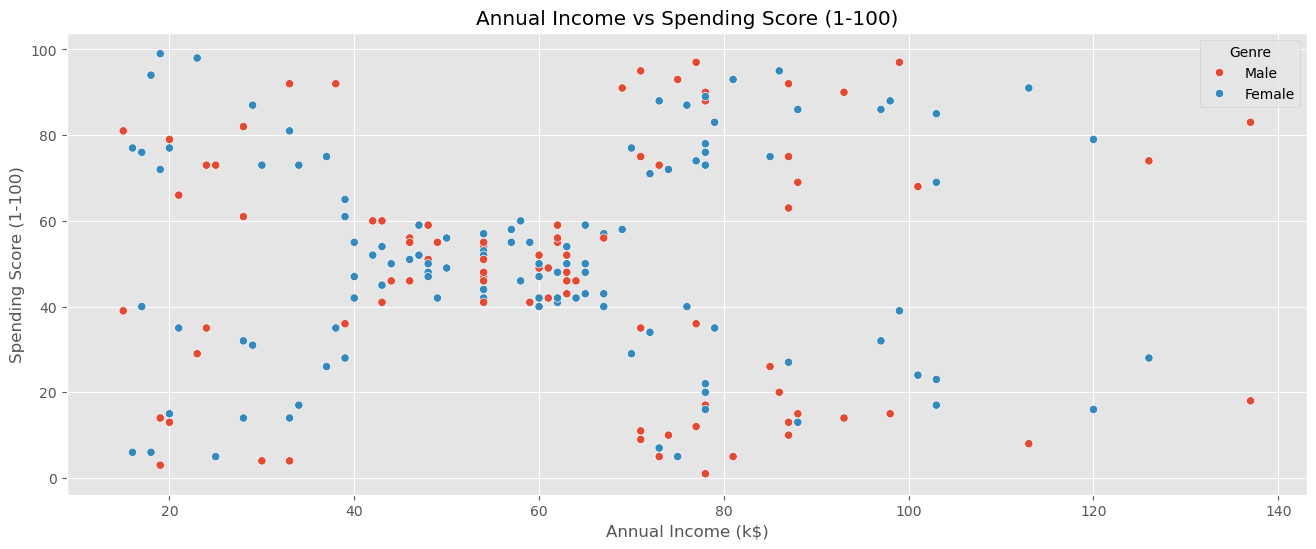

In [15]:
plt.figure(figsize=(16,6))
sns.scatterplot(x = data['Annual Income (k$)'], y=data['Spending Score (1-100)'], hue=data['Genre'])
plt.title('Annual Income vs Spending Score (1-100)')

We can see that there is no change in the dataset.

In [16]:
from sklearn.cluster import KMeans
inertias = []
clusters = range(1,11)
for c in clusters: 

    km = KMeans(n_clusters=c)
    km.fit_predict(data_scaled[['Annual Income (k$)', 'Annual Income (k$)']])
    inertias.append(km.inertia_)

Text(0, 0.5, 'Inertia')

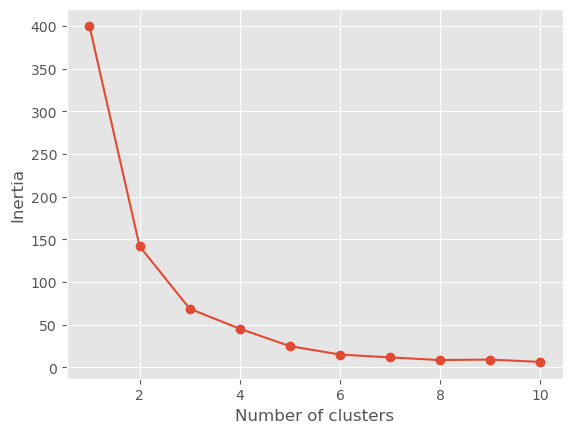

In [17]:
plt.plot(clusters, inertias, '-o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

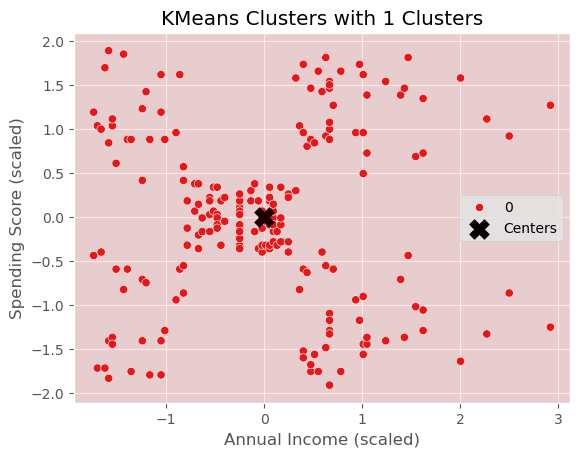

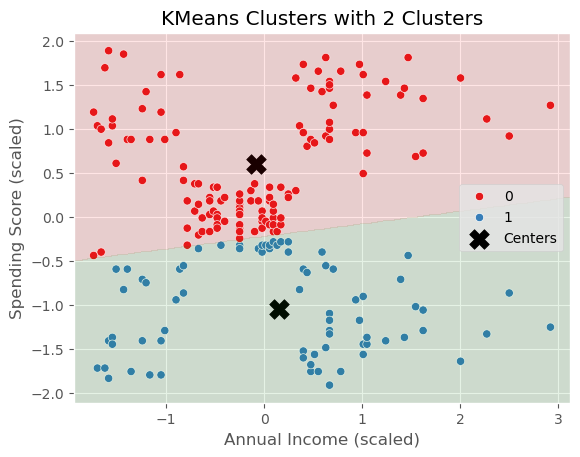

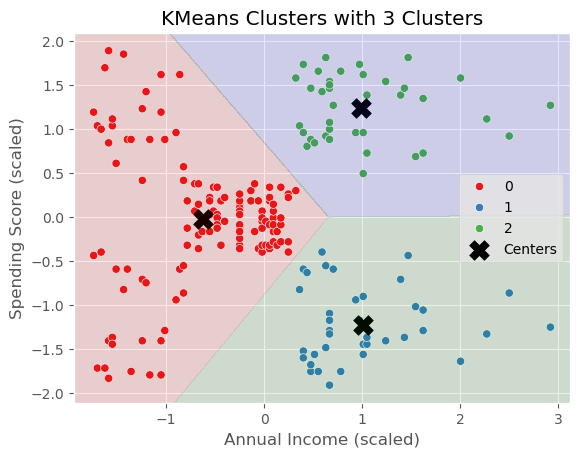

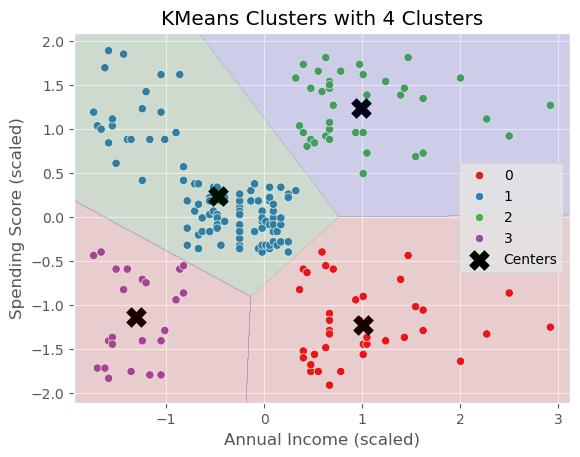

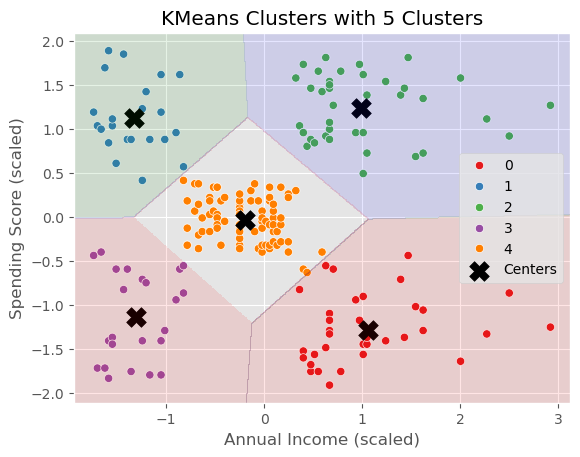

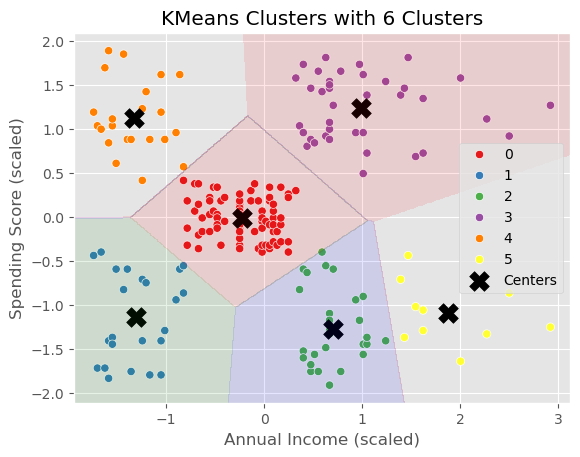

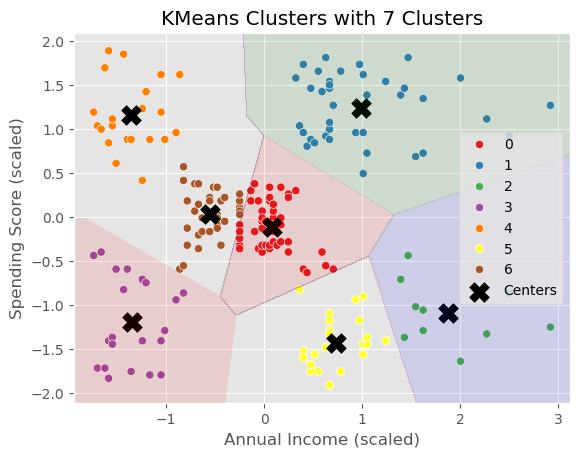

In [18]:
# plt.figure(figsize=(16,6))
i = 0
clustr = range(1,8)
for c in clustr:
    i = i+1

    # Fit KMeans with 3 clusters on scaled data
    kmeans = KMeans(n_clusters=c)
    clusters = kmeans.fit_predict(data_scaled[['Annual Income (k$)', 'Spending Score (1-100)']])

    # Plot points colored by assigned cluster
    sns.scatterplot( x=data_scaled['Annual Income (k$)'],  y=data_scaled['Spending Score (1-100)'],  hue=clusters, palette='Set1', legend='full' )

    # Plot cluster centers
    centers = kmeans.cluster_centers_   
    plt.scatter( centers[:, 0], centers[:, 1], c='black', s=200, marker='X', label='Centers' )

    # Create meshgrid for boundaries
    x = data_scaled['Annual Income (k$)']
    y = data_scaled['Spending Score (1-100)']
    x_min, x_max = x.min() - 0.2, x.max() + 0.2
    y_min, y_max = y.min() - 0.2, y.max() + 0.2
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = kmeans.predict(grid_points)
    Z = Z.reshape(xx.shape)

    # Plot KMeans boundaries
    plt.contourf(xx, yy, Z, alpha=0.1, levels=np.arange(-0.5, 4), colors=['r','g','b'])

    plt.xlabel('Annual Income (scaled)')
    plt.ylabel('Spending Score (scaled)')
    plt.title(f'KMeans Clusters with {c} Clusters')
    plt.legend()
    plt.show()


We can see here that there are 5 clusters that must be present.

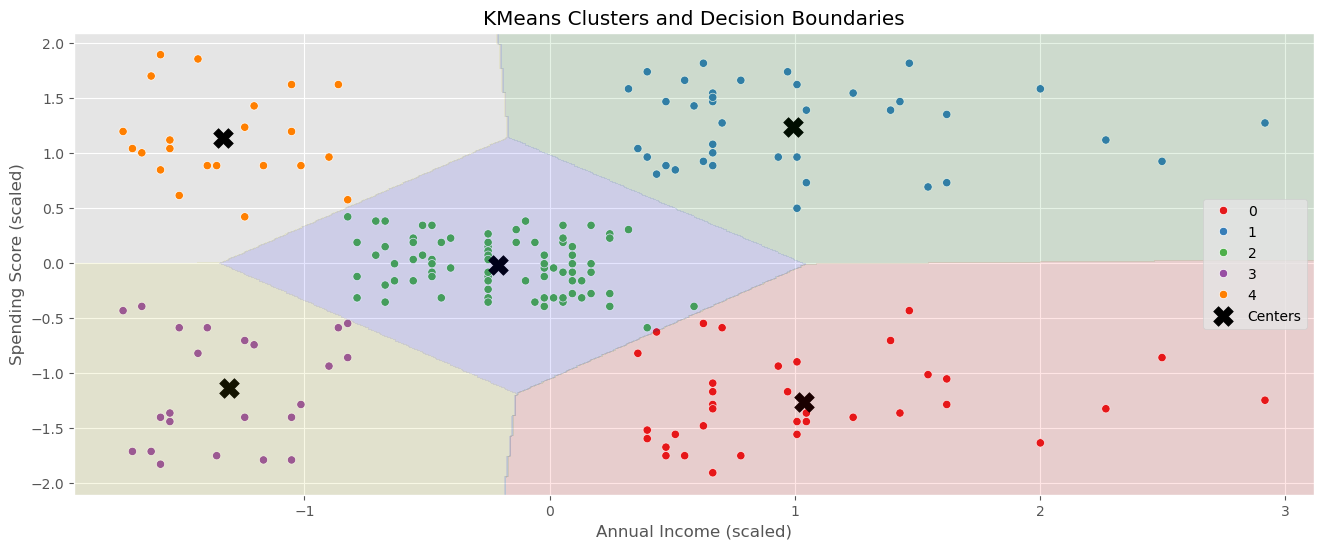

In [19]:
plt.figure(figsize=(16,6))

# Fit KMeans with 3 clusters on scaled data
kmeans = KMeans(n_clusters=5)
clusters = kmeans.fit_predict(data_scaled[['Annual Income (k$)', 'Spending Score (1-100)']])

# Plot points colored by assigned cluster
sns.scatterplot( x=data_scaled['Annual Income (k$)'],  y=data_scaled['Spending Score (1-100)'],  hue=clusters, palette='Set1', legend='full' )

# Plot cluster centers
centers = kmeans.cluster_centers_
plt.scatter( centers[:, 0], centers[:, 1], c='black', s=200, marker='X', label='Centers' )

# Create meshgrid for boundaries
x = data_scaled['Annual Income (k$)']
y = data_scaled['Spending Score (1-100)']
x_min, x_max = x.min() - 0.2, x.max() + 0.2
y_min, y_max = y.min() - 0.2, y.max() + 0.2
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = kmeans.predict(grid_points)
Z = Z.reshape(xx.shape)

# Plot KMeans boundaries
plt.contourf(xx, yy, Z, alpha=0.1, levels=np.arange(-0.5, 4), colors=['r','g','b','y','c'])

plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.title('KMeans Clusters and Decision Boundaries')
plt.legend()
plt.show()


In [20]:
data_with_clusters = data.copy()
data_with_clusters['Cluster'] = kmeans.labels_
data_with_clusters

,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,Male,19,15,39,3
1,Male,21,15,81,4
2,Female,20,16,6,3
3,Female,23,16,77,4
4,Female,31,17,40,3
...,...,...,...,...,...
195,Female,35,120,79,1
196,Female,45,126,28,0
197,Male,32,126,74,1
198,Male,32,137,18,0


In [21]:
# Assign cluster labels to the original (unscaled) data for interpretability
data_with_clusters = data.copy()
data_with_clusters['Cluster'] = kmeans.labels_

# Calculate cluster profile statistics
cluster_profiles = data_with_clusters.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean().round(2)
cluster_sizes = data_with_clusters['Cluster'].value_counts().sort_index()
cluster_profiles['Count'] = cluster_sizes

# Display cluster profiles
print("Cluster Profiles (Mean Annual Income, Spending Score, and Size):")
display(cluster_profiles)


Cluster Profiles (Mean Annual Income, Spending Score, and Size):


,Annual Income (k$),Spending Score (1-100),Count
Cluster,,,
0,87.75,17.58,36
1,86.54,82.13,39
2,55.09,49.71,80
3,26.30,20.91,23
4,25.73,79.36,22


We can see 5 different types of clusters. 
- Low-Income Low-Spenders
- Low-Income High-Spenders
- Medium-Income Medium-Spenders
- High-Income Low-Spenders
- High-Income High-Spenders

### Cluster Behavioral Patterns:
1. Low-Income Low-Spenders: Customers in this group tend to have lower annual incomes and also spend less. They may be budget-conscious or have less purchasing power.
2. Low-Income High-Spenders: Despite having a lower income, these customers spend a lot. They might value certain products very highly or spend beyond their means.
3. Medium-Income Medium-Spenders: Customers in this segment represent a balance; they have average income and exhibit moderate spending behavior. This group may be stable or regular shoppers.
4. High-Income Low-Spenders: These individuals have high incomes but spend relatively less, possibly indicating a cautious or selective approach to shopping.
5. High-Income High-Spenders: Customers with both high income and high spending. They are likely premium or luxury buyers and could be targeted for high-value offerings.


## Hierarchical Clustering

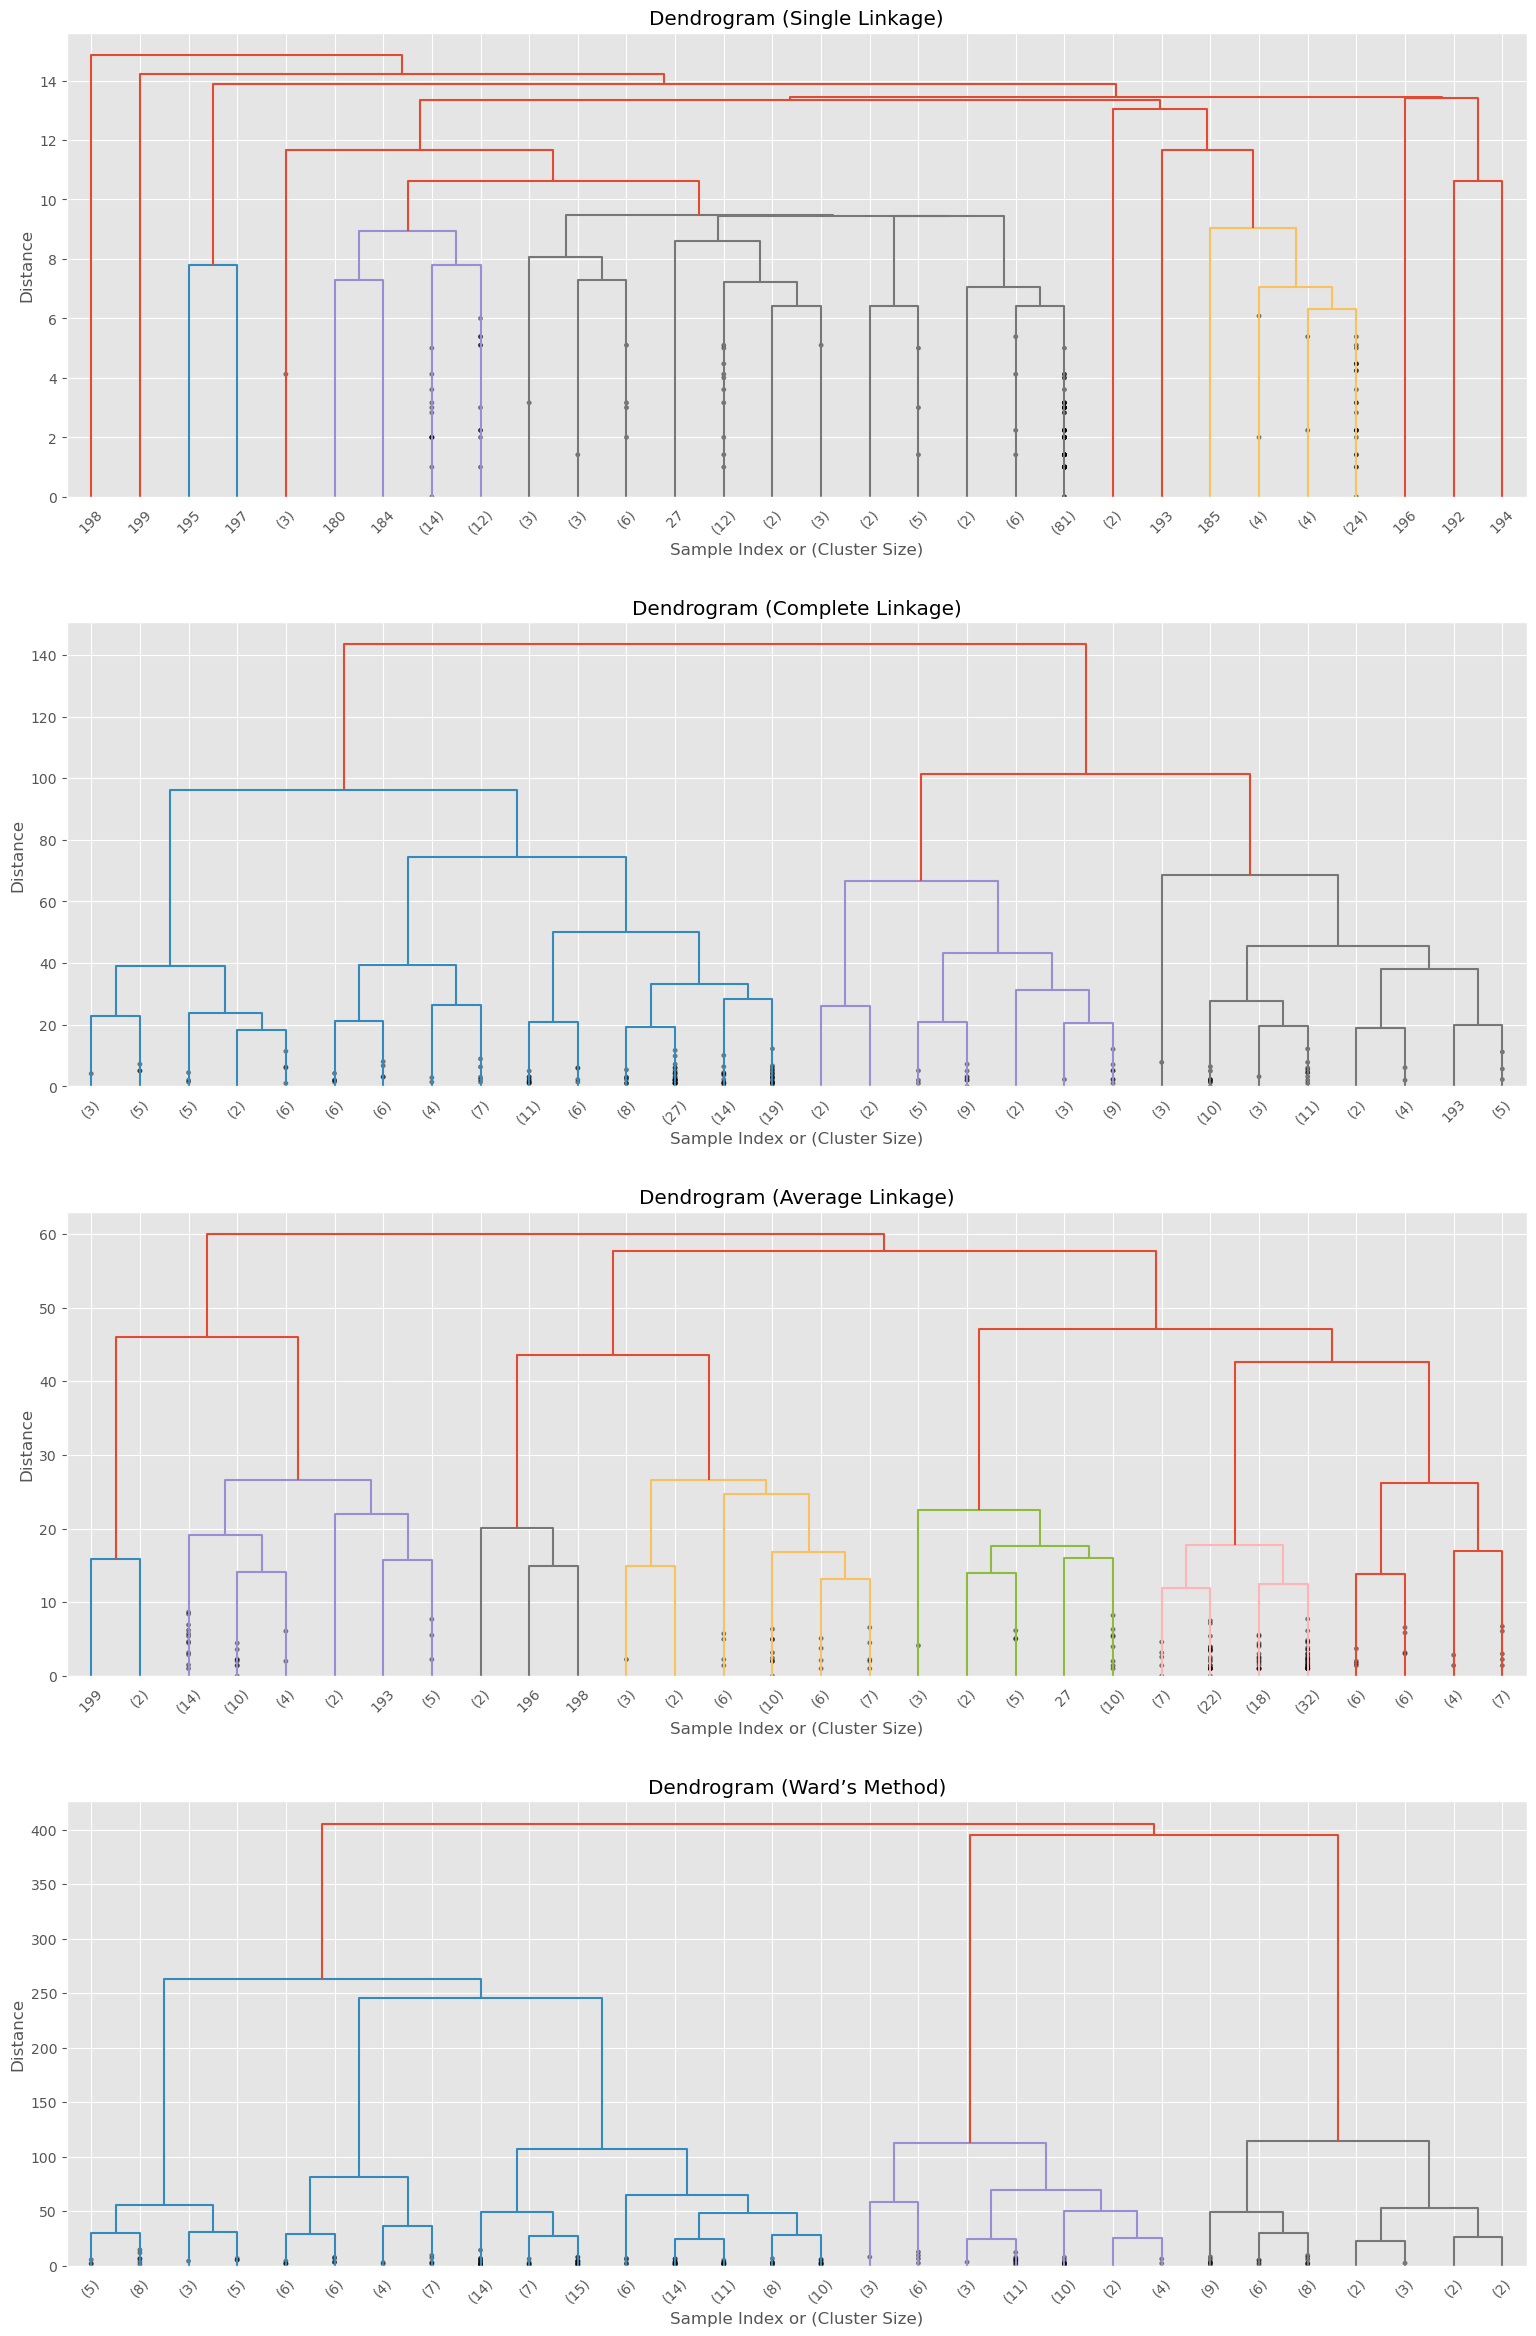


Observe the vertical distances in the dendrograms to suggest a proper cut. 
A large jump in the vertical distance before clusters merge suggests a suitable number of clusters there.
For example, for Ward's method, look for the largest vertical gap before clusters are combined on the y-axis.



In [22]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Select features for clustering - using Annual Income and Spending Score as before
X = data[['Annual Income (k$)', 'Spending Score (1-100)']].values

linkage_methods = {
    "Single Linkage": 'single',
    "Complete Linkage": 'complete',
    "Average Linkage": 'average',
    "Ward’s Method": 'ward'
}

plt.figure(figsize=(16, 24))

for i, (title, method) in enumerate(linkage_methods.items(), 1):
    plt.subplot(4, 1, i)
    Z = linkage(X, method)
    dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=45., leaf_font_size=10., show_contracted=True)
    plt.title(f'Dendrogram ({title})')
    plt.xlabel('Sample Index or (Cluster Size)')
    plt.ylabel('Distance')
    # Optionally, label the distance where it may be best to cut the dendrogram (user will visually inspect)

plt.tight_layout(pad=3.0)
plt.show()

print("""
Observe the vertical distances in the dendrograms to suggest a proper cut. 
A large jump in the vertical distance before clusters merge suggests a suitable number of clusters there.
For example, for Ward's method, look for the largest vertical gap before clusters are combined on the y-axis.
""")


In [29]:
from sklearn import metrics

# For K-Means (already done): Evaluate clustering on Annual Income and Spending Score
X_kmeans = data[['Annual Income (k$)', 'Spending Score (1-100)']].values
labels_kmeans = data_with_clusters['Cluster'].values

silhouette_kmeans = metrics.silhouette_score(X_kmeans, labels_kmeans)
dbi_kmeans = metrics.davies_bouldin_score(X_kmeans, labels_kmeans)

print(f"K-Means Clustering:\n  Silhouette Score: {silhouette_kmeans:.3f}\n  Davies-Bouldin Index: {dbi_kmeans:.3f}")

# For Hierarchical Clustering: Using Agglomerative Clustering for same features and cluster count as K-Means
from sklearn.cluster import AgglomerativeClustering

# Use number of clusters found in K-Means (data_with_clusters['Cluster'].nunique())
n_clusters = data_with_clusters['Cluster'].nunique()
agg = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
labels_hier = agg.fit_predict(X_kmeans)

silhouette_hier = metrics.silhouette_score(X_kmeans, labels_hier)
dbi_hier = metrics.davies_bouldin_score(X_kmeans, labels_hier)

print(f"\nAgglomerative (Hierarchical, Ward’s method):\n  Silhouette Score: {silhouette_hier:.3f}\n  Davies-Bouldin Index: {dbi_hier:.3f}")



K-Means Clustering:
  Silhouette Score: 0.553
  Davies-Bouldin Index: 0.571

Agglomerative (Hierarchical, Ward’s method):
  Silhouette Score: 0.553
  Davies-Bouldin Index: 0.578


In [ ]:
data_with_clusters.columns


Index(['Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)',
       'Cluster'],
      dtype='object')

In [30]:
import plotly.express as px

# Use a valid colorscale for plotly (e.g., 'Viridis', 'Plasma', 'Rainbow' for numeric color)
# For discrete clusters, use 'color_discrete_sequence'
fig = px.scatter_3d(
    data_with_clusters, 
    x='Age', 
    y='Annual Income (k$)', 
    z='Spending Score (1-100)', 
    color='Cluster', 
    symbol='Cluster',
    title='3D Scatterplot of Clusters',
    height=800,
    width=1000,
    color_discrete_sequence=px.colors.qualitative.Set1  # Use Set1 as a discrete qualitative palette
)
fig.update_traces(marker=dict(size=6))
fig.update_layout(
    legend_title_text='Cluster',
    scene = dict(
        xaxis_title='Age',
        yaxis_title='Annual Income (k$)',
        zaxis_title='Spending Score (1-100)'
    )
)
fig.show()
